# Trabalho 5 – Regressão SVM com PCA

## Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

## Preparando a base de dados

In [2]:
StudantPerformance_df = pd.read_csv('Student_Performance.csv')

StudantPerformance_df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


### Convertendo a variável categórica (Extracurricular Activities) para 0 e 1

0 -> Não \
1 -> Sim

In [3]:
col = 'Extracurricular Activities'
if StudantPerformance_df[col].dropna().isin(['Yes', 'No']).all():
    StudantPerformance_df[col] = StudantPerformance_df[col].map({'Yes': 1, 'No': 0})

StudantPerformance_df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


Verificando colunas com valores nulos

In [4]:
print(StudantPerformance_df.isnull().sum())

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


Como muitos dados são inteiros, é meio complicado visualizar os gráficos de disperção (os pontos se sobrepõem).

## Otimizando hiperparâmetros

### Reduzindo o número de amostras (para o algorítmo rodar mais rápido)

In [6]:
sample_df = StudantPerformance_df.sample(n=2000, random_state=42).reset_index(drop=True)
sample_df.shape

# Separando X e y
X = sample_df.drop('Performance Index', axis=1).values
y = sample_df['Performance Index'].values

# Hold-Out (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Normalizando com base no treino
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Usando hold-out no grid search (ao invés de Kfold) para reduzir o tempo de execução

In [7]:
# Grid de hiperparâmetros
kernels = ['linear', 'rbf', 'poly']
Cs = [1e-2, 1e-1, 1, 10, 100]
gammas = [1e-2, 1e-1, 1, 10, 100]

results = []

for kernel in kernels:
    for C in Cs:
        if kernel == 'linear':
            model = SVR(kernel=kernel, C=C)
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            mse = mean_squared_error(y_test, y_pred)
            results.append({'kernel': kernel, 'C': C, 'gamma': 'N/A', 'mse': mse})
        else:
            for gamma in gammas:
                if kernel == 'poly':
                    model = SVR(kernel=kernel, C=C, gamma=gamma, degree=2)
                else:
                    model = SVR(kernel=kernel, C=C, gamma=gamma)
                model.fit(X_train_scaled, y_train)
                y_pred = model.predict(X_test_scaled)
                mse = mean_squared_error(y_test, y_pred)
                results.append({'kernel': kernel, 'C': C, 'gamma': gamma, 'mse': mse})

# Ordena pelo menor MSE
results = sorted(results, key=lambda x: x['mse'])

# Exibe os top 5
print("Top 5 combinações com menor MSE (Hold-Out):")
for r in results[:5]:
    print(r)

Top 5 combinações com menor MSE (Hold-Out):
{'kernel': 'linear', 'C': 1, 'gamma': 'N/A', 'mse': 3.9380158098516613}
{'kernel': 'linear', 'C': 100, 'gamma': 'N/A', 'mse': 3.9443330571660478}
{'kernel': 'linear', 'C': 10, 'gamma': 'N/A', 'mse': 3.9451064911850415}
{'kernel': 'linear', 'C': 0.1, 'gamma': 'N/A', 'mse': 3.9947630404065033}
{'kernel': 'rbf', 'C': 100, 'gamma': 0.01, 'mse': 4.058442722201453}


Parametros escolhidos:

In [8]:
best_kernel = results[0]['kernel']
best_C = results[0]['C']
best_gamma = results[0]['gamma']   

print(f"\nMelhor combinação: Kernel={best_kernel}, C={best_C}, gamma={best_gamma}")


Melhor combinação: Kernel=linear, C=1, gamma=N/A


## Implementação do PCA

In [9]:
def pca_transform(X, n_componentes=None):
    """
    Parâmetros:
    - X: matriz de entrada (amostras x variáveis)
    - n_componentes: número de componentes principais a manter (se None, usa todas)
    
    Retorna:
    - X_pca: dados projetados nos autovetores principais
    - razao_variancia: array com a razão da variância explicada por cada componente
    - autovalores: array com os autovalores (variância de cada componente)
    - autovetores: matriz com os autovetores (componentes principais)
    """

    # Centralizando os dados
    X_centralizado = X - np.mean(X, axis=0)
    
    # Calculando a matriz de covariância
    cov_matrix = np.cov(X_centralizado, rowvar=False)

    # Calculando autovalores e autovetores
    autovalores, autovetores = np.linalg.eigh(cov_matrix)

    # Ordenando em ordem decrescente de autovalores
    ordem = np.argsort(autovalores)[::-1]
    autovalores = autovalores[ordem]
    autovetores = autovetores[:, ordem]
    
    # Calculando razão da variância explicada
    soma_total = np.sum(autovalores)
    razao_variancia = autovalores / soma_total
    
    # Selecionando apenas a quantidade de componentes informada
    if n_componentes is not None:
        autovetores = autovetores[:, :n_componentes]
    
    # Projetando os dados nos autovetores escolhidos
    X_pca = np.dot(X_centralizado, autovetores)

    return X_pca, razao_variancia, autovalores, autovetores


## Avaliação dos 6 modelos de regressão

In [25]:
def evaluate_models(X, y, pca_func):
    """
    Avalia modelo SVR sem PCA e com PCA variando o número de componentes de 1 a 5.

    Parâmetros:
    - X: matriz de entrada (amostras x características)
    - y: vetor alvo
    - pca_func: função PCA customizada que retorna (X_pca, razao_var, autovalores, autovetores)

    Retorna:
    - Resultados por modelo
    """

    resultados = []

    # Dividindo base
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Sem PCA
    if best_gamma == 'N/A':
        model = SVR(kernel=best_kernel, C=best_C)
    else:   
        model = SVR(kernel=best_kernel, C=best_C, gamma=best_gamma)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    resultados.append({
        'n_componentes': 'sem_pca',
        'r2': r2,
        'mse': mse,
        'razao_variancia_explicada': None 
    })

    # Com PCA de 1 a 5 componentes
    for n in range(1, 6):
        # Aplicando o PCA aos dados de treino e teste
        X_train_pca, razao_var, autovalores, _ = pca_func(X_train, n_componentes=n)
        X_test_centralizado = X_test - np.mean(X_train, axis=0)
        X_test_pca = np.dot(X_test_centralizado, _[:, :n])

        # Treinando e avaliando os resultados
        model.fit(X_train_pca, y_train)
        y_pred = model.predict(X_test_pca)

        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        soma_var_explicada = np.sum(autovalores[:n]) / np.sum(autovalores)

        resultados.append({
            'n_componentes': n,
            'r2': r2,
            'mse': mse,
            'razao_variancia_explicada': soma_var_explicada
        })

    return resultados


### Realizando o treinamento dos 6 modelos

Componentes: sem_pca, R²: 0.9890, MSE: 4.0731, Razão Var Explicada: None
Componentes: 1, R²: 0.8413, MSE: 58.7435, Razão Var Explicada: 0.9432404941260546
Componentes: 2, R²: 0.8454, MSE: 57.2252, Razão Var Explicada: 0.9690512011514777
Componentes: 3, R²: 0.9872, MSE: 4.7404, Razão Var Explicada: 0.9901858853391432
Componentes: 4, R²: 0.9887, MSE: 4.1858, Razão Var Explicada: 0.9992163846804116
Componentes: 5, R²: 0.9890, MSE: 4.0730, Razão Var Explicada: 1.0


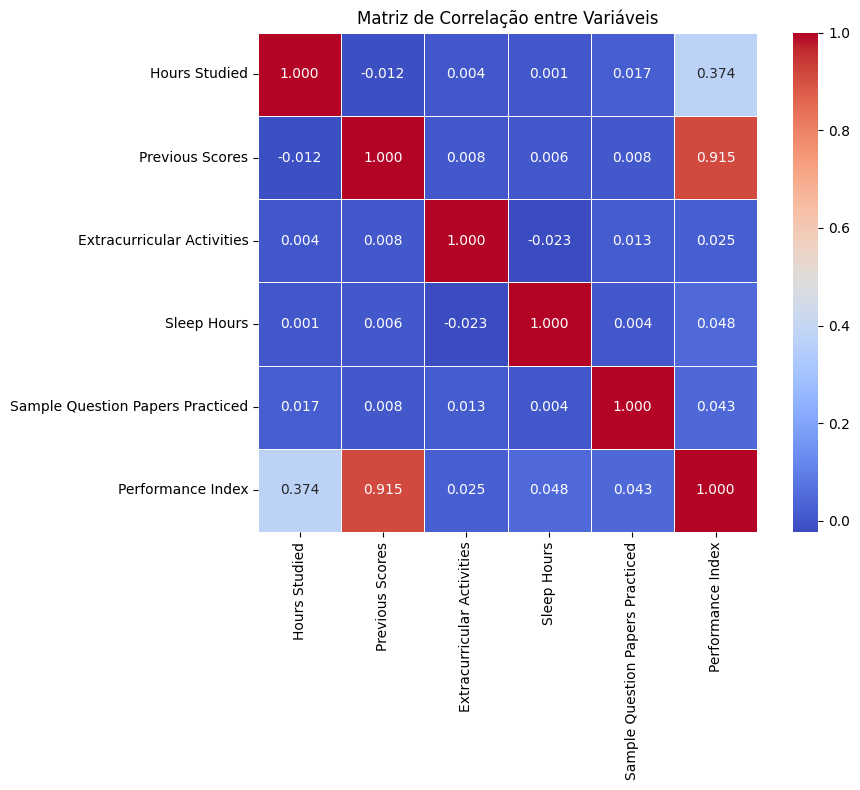

In [26]:
# Separando X e y
X = StudantPerformance_df.drop('Performance Index', axis=1).values
y = StudantPerformance_df['Performance Index'].values

# Hold-Out (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Normalizando com base no treino
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

resultados = evaluate_models(X, y, pca_transform)

# Exibe resultados
for res in resultados:
    print(f"Componentes: {res['n_componentes']}, R²: {res['r2']:.4f}, MSE: {res['mse']:.4f}, Razão Var Explicada: {res['razao_variancia_explicada']}")

# Calculando a matriz de correlação
correlation_matrix = StudantPerformance_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".3f",
    linewidths=0.5,
    square=True
)
plt.title("Matriz de Correlação entre Variáveis")
plt.tight_layout()
plt.show()

## Gráficos de dispersão dos atributos

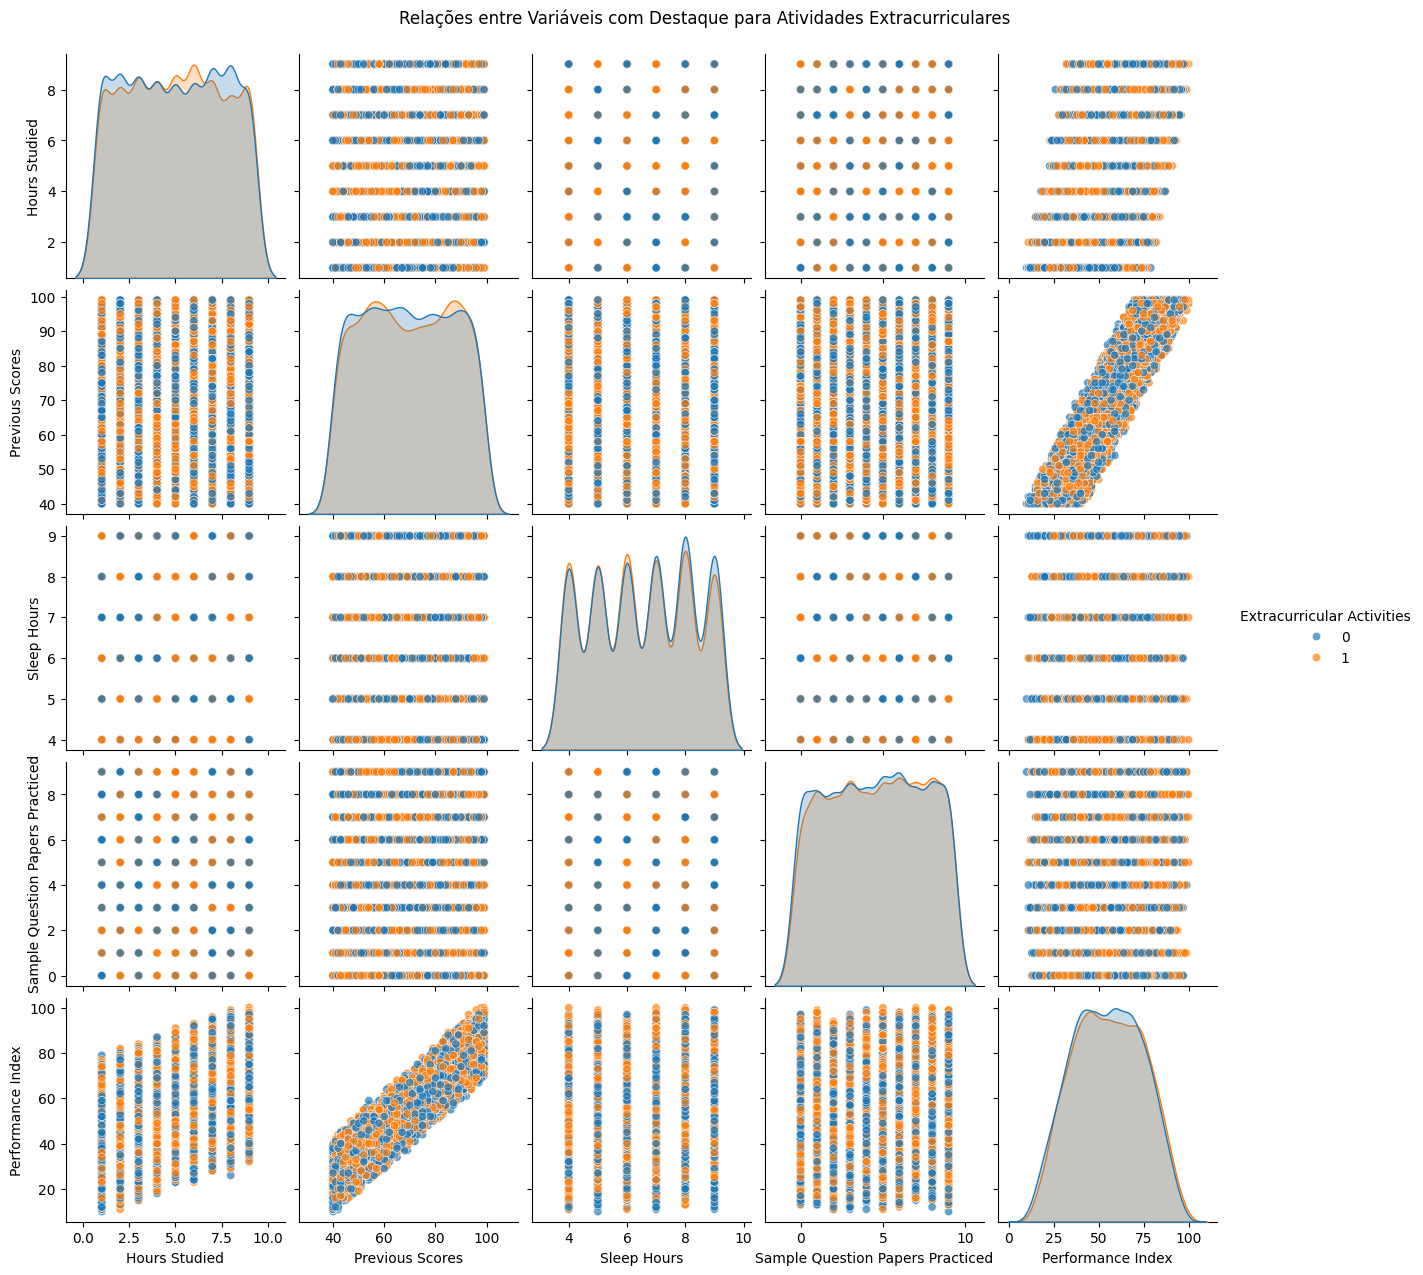

In [12]:
## Pairplot dos parametros:
sns.pairplot(
    StudantPerformance_df[[
        'Hours Studied',
        'Previous Scores',
        'Sleep Hours',
        'Sample Question Papers Practiced',
        'Performance Index',
        'Extracurricular Activities'
    ]],
    hue='Extracurricular Activities',
    plot_kws={'alpha': 0.7} 
)

plt.suptitle("Relações entre Variáveis com Destaque para Atividades Extracurriculares", y=1.02)
plt.show()


## Significado das medidas
### $R^2$ (coeficiente de determinação):
É uma medida estatística que avalia o quão bem os valores previstos por um modelo de regressão se ajustaram aos valores reais. Ele é dado por:

$$
R^2 = 1 - \frac{\text{SSE}}{\text{SST}} = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$

Em que: 

- SSE: erro entre os valores reais e os previstos.

- SST: variância total dos valores reais em relação à média.

Determina o quanto o modelo explica a variância dos dados.  

### O MSE (Mean squared error):
Determina o quão distantes estão as prediçoes do modelo em relação aos valores reais, penalizando ainda mais os erros, por ser o quadrado da diferença entre o que se esperava e o atingido.
$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$


### Razão Var Explicada (Proporção da Variância Explicada)
Medida que descreve a proporção de variância total dos dados originais que é capturada e retida pelos componentes principais selecionados, ou seja, o quanto da variância conseguimos manter com a redução de dimensionalidade que aplicamos.

| Componentes | R²     | MSE     | Razão Variância Explicada |
|-------------|--------|---------|----------------------------|
| sem_pca     | 0.9890 | 4.0731  | None                       |
| 1           | 0.8413 | 58.7435 | 0.9432                     |
| 2           | 0.8454 | 57.2252 | 0.9691                     |
| 3           | 0.9872 | 4.7404  | 0.9902                     |
| 4           | 0.9887 | 4.1858  | 0.9992                     |
| 5           | 0.9890 | 4.0730  | 1.0000                     |



1. SVR sem PCA:  
Serve como modelo base para avaliar a influência do PCA na regressão. Teve um significativo ótimo desempenho, com $R^2$ = 0.9890, bem próximo de 1, que indica que se ajustou bem aos dados. O erro quadrado médio também baixo (4.0731).

2. PCA com apenas 1 componente:  
A regressão teve um desempenho relativamente alto, porém mais baixo do que sem reduzir sua dimensão. Também ocorreram mais erros (58.7435 de MSE). Isso porque o nosso algorítmo perdeu muita variância de dados após o PCA (como pode ver, a razão de variância é de apenas 94.32%). Isso é um resultado esperado de underfiting, já que não demos ao modelo uma variedade de dados suficientemente grande para ele se ajustar bem. Por outro lado, o resultado foi impressionante considerando que a regressão usou apenas 1 atributo. Provavelmente o algorítimo do PCA capturou muito fortemente os dados de uma componente e, olhando pela matriz de correlação, provavelmente essa componente foi o atributo _"Previous Scores"_. Isso indica que, embora o primeiro componente principal capture a maior parte da variância geral dos dados, ele pode ter descartado informações cruciais para a discriminação ou previsão da sua variável alvo.

- Outro fator interessante é: Se você voltar para a célula que eu plotei os gráficos de dispersão, poderá notar que os atributos _"Previous Scores"_ e _"Performace Index"_ são diagonais (indicando correlaçao, que realmente é observada no mapa de correlação). Isso é interessante porque o modelo de SVR que melhor funcionou para nosso dataset foi o modelo linear. Outro gráfico que é levemente diagonal é o de _"Hours Studed"_ e _"Performace Index"_, e de fato observamos uma correlação significativa (porem mais baixa) nesse atributo.

3. PCA com 2 componentes principais:  
Há uma pequeníssima melhora em relação ao PCA com 1 atributo, mas o desempenho ainda é significativamente pior que o modelo sem PCA. De fato os dois componentes descrevem a maior parte da variância, mas não possuem todas as informações necessárias para descrever o problema.

4. PCA com 3 componentes principais:  
Nesse caso, a regressão teve um salto de desempenho bem alto, passando a ter um $R^2$ = 0.9872. O erro também caiu muito, por outro lado, a variancia aumentou só um pouco. De alguma forma, a combinação dessas 3 componentes possibilitou uma classificação muito melhor, ou seja, os dados conseguiram ser mais separáveis com 3 dimensões.

4. PCA com 4 componentes principais:  Houve uma pequena melhora no desempenho do SVR ($R^2$ = 0.9887), mas não foi tão grande nem significativa. O erro médio quadrado também caiu razoavelmente, (RMS= 4.1858) e a razão da variancia aumentou um pouco. Eu diria que o algoritmo converge com 3 componentes principais, com mais componentes ele tem apenas pequenas melhoras pífias.

5. PCA com 5 componentes principais: Esse foi o melhor desempenho do algorítmo SVR ($R^2$ = 0.9890), mas com melhoras pouco significativas em relação ao PCA3 e PCA4. Aqui a razão variância é máxima (1), já que não removemos nenhuma dimensão do dataset original. Outro aspecto interessante é que essa versão do PCA5 + SVR teve um resultado melhor que o algorítmo sem PCA e essa melhoria pode ser atribuída ao fato de que os componentes principais são descorrelacionados (ortogonais). A remoção da correlação entre as features feita pelo PCA pode ter ajudado o algoritmo a ter um desempenho um pouco superior.

O uso do PCA é interessante porque ele pode nos ajudar a reduzir o custo computacional de regressões, classificações etc. Isso porque ele é uma técnica de transformação de atributos que busca converter um conjunto de variáveis possivelmente correlacionadas em um conjunto de variáveis não correlacionadas, chamadas componentes principais (Evitando a redundância). O objetivo é reduzir a dimensionalidade do espaço de características, mantendo a maior parcela possível da informação.  

No nosso caso, usar PCA com 3 componentes + regressão já teria um resultado bem satisfatório no nosso algorítmo, reduzindo o número de dimensões utilizadas para a regressão. 